In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import shap
import lightgbm as lgb
from scipy.stats import spearmanr
from hmmlearn.hmm import GaussianHMM
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# load data
ml_data  = pd.read_parquet("../data/ml_data_v3.parquet")
ic_series = pd.read_parquet("../data/ic_series_v3.parquet")["ic"]
pred_df  = pd.read_parquet("../data/predictions_v3.parquet")

# trim to 2021 same as training
ml_data = ml_data.loc[
    ml_data.index.get_level_values("Date") >= "2021-01-01"
]

FEATURES = ["mom_12_1", "mom_6_1", "mom_1m", "vol_1m",
            "vol_3m", "price_to_high", "reversal_5d", "vol_ratio"]
TARGET   = "label"

print(f"ml_data  : {ml_data.shape}")
print(f"ic_series: {len(ic_series)} months")
print(f"pred_df  : {pred_df.shape}")
print("all loaded")

ml_data  : (484412, 9)
ic_series: 22 months
pred_df  : (10911, 2)
all loaded


In [2]:
# ── TRAIN FINAL MODEL FOR SHAP ───────────────────────────────────
# Train on all data up to last 3 months
# We just need a fitted model to explain — not for prediction

cutoff = ml_data.index.get_level_values("Date").unique().sort_values()[-63]

train_data = ml_data.loc[
    ml_data.index.get_level_values("Date") <= cutoff
]

X_train = train_data[FEATURES]
y_train = train_data[TARGET]

model = lgb.LGBMRegressor(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 20,
    random_state     = 42,
    verbose          = -1
)
model.fit(X_train, y_train)

print(f"trained on {len(X_train):,} samples")
print(f"features: {FEATURES}")

trained on 453,559 samples
features: ['mom_12_1', 'mom_6_1', 'mom_1m', 'vol_1m', 'vol_3m', 'price_to_high', 'reversal_5d', 'vol_ratio']


In [3]:
# ── SHAP ANALYSIS ─────────────────────────────────────────────────
# Use a sample of 2000 rows — full dataset is too slow for SHAP
# Random sample is fine, we just want representative explanations

sample = X_train.sample(2000, random_state=42)

# TreeExplainer is optimised for LightGBM — very fast
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

print(f"shap_values shape: {shap_values.shape}")
print("SHAP computed successfully")

shap_values shape: (2000, 8)
SHAP computed successfully


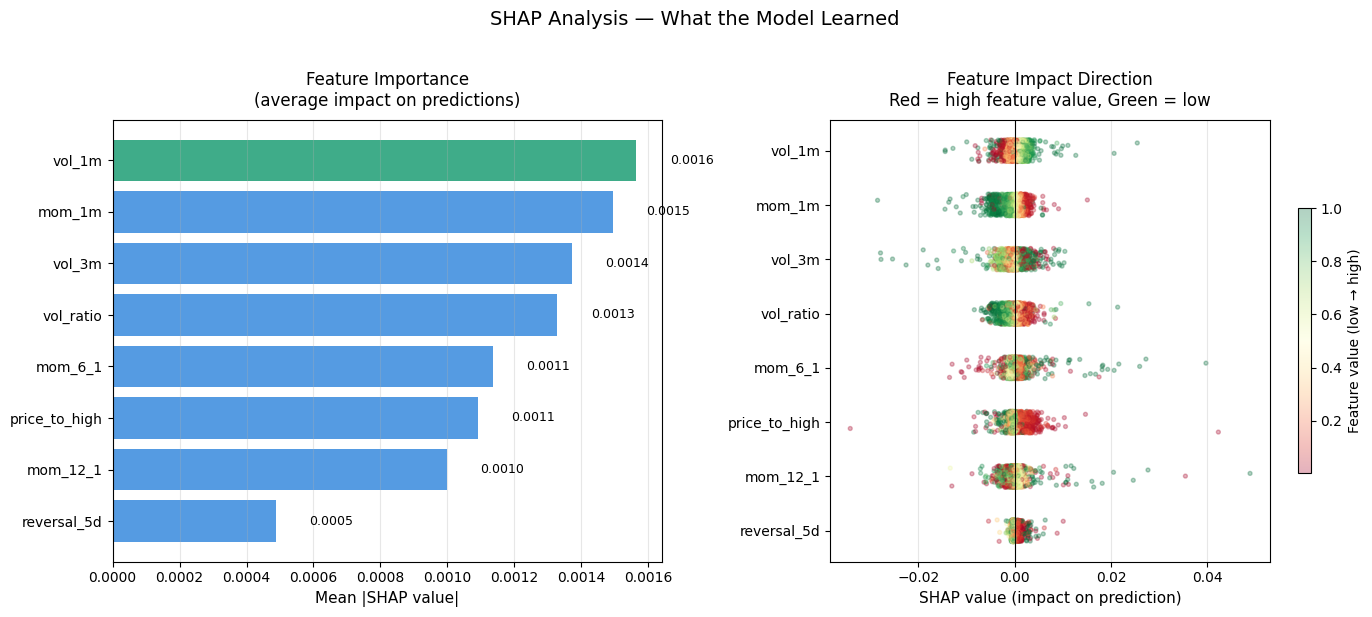

shap chart saved


In [4]:
# ── SHAP PLOTS ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── left: bar chart — mean absolute SHAP by feature ──────────────
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.Series(mean_shap, index=FEATURES).sort_values()

colors = ["#1D9E75" if v == feature_importance.max() 
          else "#378ADD" for v in feature_importance.values]

axes[0].barh(feature_importance.index, feature_importance.values, 
             color=colors, alpha=0.85)
axes[0].set_xlabel("Mean |SHAP value|", fontsize=11)
axes[0].set_title("Feature Importance\n(average impact on predictions)", 
                   fontsize=12, pad=10)
axes[0].grid(axis="x", alpha=0.3)
for i, (val, name) in enumerate(zip(feature_importance.values, 
                                     feature_importance.index)):
    axes[0].text(val + 0.0001, i, f"{val:.4f}", 
                 va="center", fontsize=9)

# ── right: beeswarm-style scatter per feature ────────────────────
ax2 = axes[1]
feature_order = feature_importance.sort_values(ascending=False).index.tolist()

for i, feat in enumerate(reversed(feature_order)):
    feat_idx   = FEATURES.index(feat)
    shap_vals  = shap_values[:, feat_idx]
    feat_vals  = sample[feat].values
    
    # color by feature value — red = high, blue = low
    scatter = ax2.scatter(
        shap_vals,
        np.full(len(shap_vals), i) + np.random.uniform(-0.2, 0.2, len(shap_vals)),
        c=feat_vals,
        cmap="RdYlGn",
        alpha=0.3,
        s=8
    )

ax2.set_yticks(range(len(feature_order)))
ax2.set_yticklabels(reversed(feature_order), fontsize=10)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("SHAP value (impact on prediction)", fontsize=11)
ax2.set_title("Feature Impact Direction\nRed = high feature value, Green = low", 
               fontsize=12, pad=10)
ax2.grid(axis="x", alpha=0.3)

plt.colorbar(scatter, ax=ax2, label="Feature value (low → high)", 
             shrink=0.6)
plt.suptitle("SHAP Analysis — What the Model Learned", 
              fontsize=14, fontweight="500", y=1.02)
plt.tight_layout()
plt.savefig("../data/shap_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("shap chart saved")

In [5]:
# ── HMM REGIME DETECTION ─────────────────────────────────────────
# Train a 2-state HMM on SPY returns to label market regimes
# Then show how model IC varies by regime

# pull SPY data for the full period
spy = yf.download("SPY", start="2021-01-01", end="2024-12-31", 
                  auto_adjust=True, progress=False)
spy_returns = spy["Close"].pct_change().dropna()

# prepare observation sequence for HMM
# use returns + rolling volatility as two observations
spy_vol = spy_returns.rolling(21).std()
obs = pd.concat([spy_returns, spy_vol], axis=1).dropna()
obs.columns = ["return", "vol"]

# standardise observations
obs_scaled = (obs - obs.mean()) / obs.std()

# fit 2-state Gaussian HMM
hmm = GaussianHMM(
    n_components = 2,
    covariance_type = "full",
    n_iter = 100,
    random_state = 42
)
hmm.fit(obs_scaled.values)

# decode hidden states for every day
states = hmm.predict(obs_scaled.values)
state_series = pd.Series(states, index=obs_scaled.index)

# identify which state is "calm" vs "stressed"
# calm state = lower average volatility
state_vols = {s: obs["vol"][state_series == s].mean() for s in [0, 1]}
calm_state    = min(state_vols, key=state_vols.get)
stressed_state = 1 - calm_state

print(f"calm state    : State {calm_state} "
      f"(avg vol: {state_vols[calm_state]:.4f})")
print(f"stressed state: State {stressed_state} "
      f"(avg vol: {state_vols[stressed_state]:.4f})")
print(f"days in calm    : {(state_series == calm_state).sum()}")
print(f"days in stressed: {(state_series == stressed_state).sum()}")

calm state    : State 1 (avg vol: 0.0071)
stressed state: State 0 (avg vol: 0.0135)
days in calm    : 583
days in stressed: 400


In [6]:
# ── MAP REGIMES TO MONTHS + SPLIT IC ─────────────────────────────
# For each month in our IC series, label it calm or stressed
# based on the dominant HMM state that month

# get monthly dominant state
monthly_state = state_series.resample("ME").apply(
    lambda x: x.mode()[0] if len(x) > 0 else np.nan
)

# align with IC series dates
# normalize both indexes to month-end for joining
ic_df = ic_series.to_frame(name="ic")
ic_df.index = pd.to_datetime(ic_df.index).to_period("M").to_timestamp("M")

monthly_state.index = monthly_state.index.to_period("M").to_timestamp("M")

# join
combined = ic_df.join(monthly_state.rename("state"), how="left")
combined["regime"] = combined["state"].map({
    calm_state    : "Calm",
    stressed_state: "Stressed"
})

print(combined[["ic", "regime"]].to_string())

                  ic    regime
2023-02-28  0.035414  Stressed
2023-03-31  0.033298  Stressed
2023-04-30 -0.038721      Calm
2023-05-31 -0.182648      Calm
2023-06-30 -0.016368      Calm
2023-07-31 -0.053815      Calm
2023-08-31 -0.059444      Calm
2023-09-30 -0.034268      Calm
2023-10-31  0.053771      Calm
2023-11-30 -0.053232      Calm
2023-12-31  0.177240      Calm
2024-01-31  0.185633      Calm
2024-02-29  0.003283      Calm
2024-03-31 -0.134782      Calm
2024-04-30  0.131601      Calm
2024-05-31  0.068349      Calm
2024-06-30 -0.082036      Calm
2024-07-31 -0.126545      Calm
2024-08-31  0.097000  Stressed
2024-09-30  0.215736      Calm
2024-10-31  0.093547      Calm
2024-11-30 -0.021967      Calm


── IC by Regime ────────────────────────
  Calm     : 0.0066  (19 months)
  Stressed : 0.0552  (3 months)
  Overall  : 0.0132  (22 months)
────────────────────────────────────────


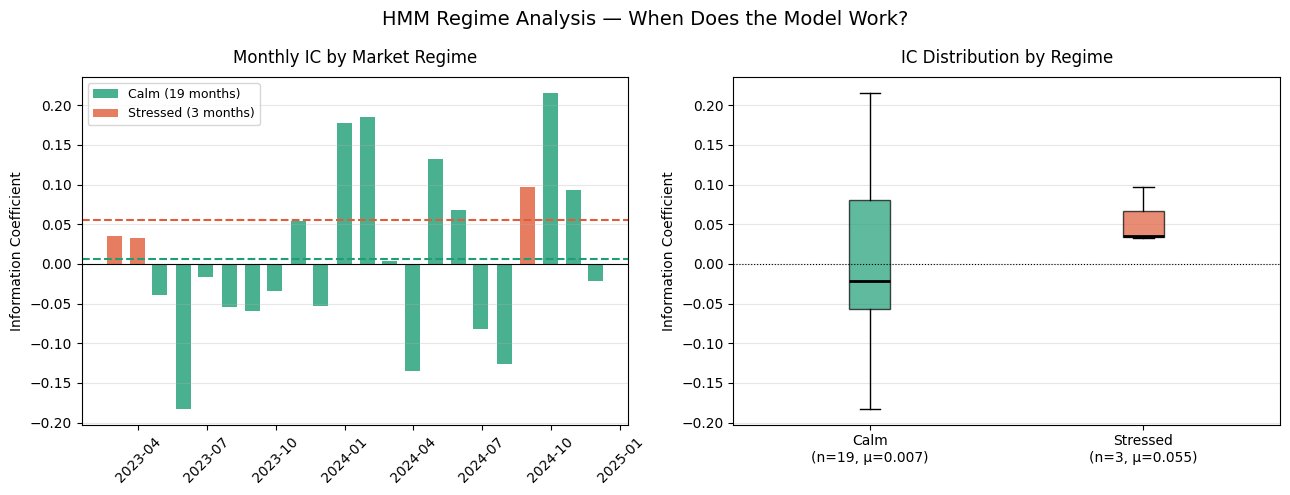

regime chart saved


In [7]:
# ── IC BY REGIME CHART ────────────────────────────────────────────
calm_ic     = combined[combined["regime"] == "Calm"]["ic"]
stressed_ic = combined[combined["regime"] == "Stressed"]["ic"]

calm_mean     = calm_ic.mean()
stressed_mean = stressed_ic.mean()

print("── IC by Regime ────────────────────────")
print(f"  Calm     : {calm_mean:.4f}  ({len(calm_ic)} months)")
print(f"  Stressed : {stressed_mean:.4f}  ({len(stressed_ic)} months)")
print(f"  Overall  : {combined['ic'].mean():.4f}  ({len(combined)} months)")
print("────────────────────────────────────────")

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: IC over time coloured by regime ────────────────────────
ax1 = axes[0]
for idx, row in combined.iterrows():
    color = "#1D9E75" if row["regime"] == "Calm" else "#E05C3A"
    ax1.bar(idx, row["ic"], color=color, alpha=0.8, width=20)

ax1.axhline(0,            color="black",   linewidth=0.8)
ax1.axhline(calm_mean,    color="#1D9E75", linewidth=1.5,
            linestyle="--", label=f"Calm mean IC = {calm_mean:.3f}")
ax1.axhline(stressed_mean,color="#E05C3A", linewidth=1.5,
            linestyle="--", label=f"Stressed mean IC = {stressed_mean:.3f}")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", alpha=0.8, label=f"Calm ({len(calm_ic)} months)"),
    Patch(facecolor="#E05C3A", alpha=0.8, label=f"Stressed ({len(stressed_ic)} months)"),
]
ax1.legend(handles=legend_elements, fontsize=9)
ax1.set_title("Monthly IC by Market Regime", fontsize=12, pad=10)
ax1.set_ylabel("Information Coefficient")
ax1.grid(axis="y", alpha=0.3)
ax1.tick_params(axis="x", rotation=45)

# ── right: box plot IC distribution by regime ────────────────────
ax2 = axes[1]
data_to_plot = [calm_ic.values, stressed_ic.values]
bp = ax2.boxplot(data_to_plot, patch_artist=True,
                  medianprops=dict(color="black", linewidth=2))

bp["boxes"][0].set_facecolor("#1D9E75")
bp["boxes"][0].set_alpha(0.7)
if len(bp["boxes"]) > 1:
    bp["boxes"][1].set_facecolor("#E05C3A")
    bp["boxes"][1].set_alpha(0.7)

ax2.set_xticklabels([
    f"Calm\n(n={len(calm_ic)}, μ={calm_mean:.3f})",
    f"Stressed\n(n={len(stressed_ic)}, μ={stressed_mean:.3f})"
])
ax2.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax2.set_title("IC Distribution by Regime", fontsize=12, pad=10)
ax2.set_ylabel("Information Coefficient")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("HMM Regime Analysis — When Does the Model Work?",
             fontsize=14, fontweight="500")
plt.tight_layout()
plt.savefig("../data/regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("regime chart saved")

In [8]:
import os
for f in sorted(os.listdir("../data")):
    size = os.path.getsize(f"../data/{f}") / 1024 / 1024
    print(f"  {f:<35} {size:.1f} MB")

  ic_over_time.png                    0.1 MB
  ic_series.parquet                   0.0 MB
  ic_series_v3.parquet                0.0 MB
  ml_data.parquet                     9.7 MB
  ml_data_v3.parquet                  12.6 MB
  predictions.parquet                 0.2 MB
  predictions_v3.parquet              0.2 MB
  quintile_fan_chart.png              0.2 MB
  regime_analysis.png                 0.1 MB
  shap_analysis.png                   0.2 MB
  sp500_raw.parquet                   29.8 MB


In [9]:
import shutil
import os

# create images folder at project root level
os.makedirs("../images", exist_ok=True)

# copy all charts there
charts = [
    "ic_over_time.png",
    "quintile_fan_chart.png", 
    "shap_analysis.png",
    "regime_analysis.png"
]

for chart in charts:
    shutil.copy(f"../data/{chart}", f"../images/{chart}")
    print(f"copied {chart}")

print("\nimages folder ready")

copied ic_over_time.png
copied quintile_fan_chart.png
copied shap_analysis.png
copied regime_analysis.png

images folder ready
